# 01 — Segmentação de Grãos de Café Verde

**Objetivo:** Carregar o dataset, explorar as classes disponíveis e comparar dois métodos de segmentação para isolar o grão de café do fundo da imagem.

**Métodos comparados:**
1. **Método A:** Limiarização adaptativa no espaço HSV + operações morfológicas
2. **Método B:** Detecção de bordas Canny + fechamento morfológico + preenchimento de contornos

Ao final, os recortes (crops) de cada grão são salvos para uso nos próximos notebooks.

In [1]:
# ── Imports ──────────────────────────────────────────────────────────────────
import os
import sys
import json
import pickle
import warnings
import numpy as np
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from pathlib import Path
from tqdm.notebook import tqdm
from collections import Counter

warnings.filterwarnings('ignore')

# Semente global
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

# Diretórios de saída
OUTPUTS_DIR = Path('../outputs')
OUTPUTS_DIR.mkdir(exist_ok=True)

print('Imports carregados com sucesso.')

Imports carregados com sucesso.


## 1. Download e carregamento do dataset

In [2]:
import kagglehub

# Download do dataset
path = kagglehub.dataset_download('sujitraarw/coffee-green-bean-with-17-defects-original')
print('Dataset path:', path)
DATASET_PATH = Path(path)

Dataset path: C:\Users\vitor\.cache\kagglehub\datasets\sujitraarw\coffee-green-bean-with-17-defects-original\versions\1


In [3]:
# ── Descobrir a raiz das classes ──────────────────────────────────────────────
# O dataset pode estar aninhado; procuramos a pasta que contém subpastas de classes
def find_class_root(base_path: Path) -> Path:
    """Percorre subpastas até encontrar diretório com subpastas de classes."""
    for root, dirs, files in os.walk(base_path):
        root = Path(root)
        img_dirs = [d for d in dirs if not d.startswith('.')]
        # Verifica se subpastas contêm imagens
        if img_dirs:
            sub = root / img_dirs[0]
            imgs = list(sub.glob('*.jpg')) + list(sub.glob('*.png')) + list(sub.glob('*.jpeg'))
            if imgs:
                return root
    return base_path

CLASS_ROOT = find_class_root(DATASET_PATH)
print(f'Raiz das classes encontrada: {CLASS_ROOT}')

# Lista das classes
CLASS_NAMES = sorted([d.name for d in CLASS_ROOT.iterdir()
                      if d.is_dir() and not d.name.startswith('.')])
print(f'\nClasses encontradas ({len(CLASS_NAMES)}):')
for c in CLASS_NAMES:
    print(f'  {c}')

Raiz das classes encontrada: C:\Users\vitor\.cache\kagglehub\datasets\sujitraarw\coffee-green-bean-with-17-defects-original\versions\1

Classes encontradas (17):
  Broken
  Cut
  Dry Cherry
  Fade
  Floater
  Full Black
  Full Sour
  Fungus Damange
  Husk
  Immature
  Parchment
  Partial Black
  Partial Sour
  Severe Insect Damange
  Shell
  Slight Insect Damage
  Withered


In [4]:
# ── Inventário do dataset ─────────────────────────────────────────────────────
EXTENSIONS = {'.jpg', '.jpeg', '.png', '.bmp'}

def list_images(class_dir: Path) -> list:
    imgs = []
    for ext in EXTENSIONS:
        imgs.extend(class_dir.glob(f'*{ext}'))
        imgs.extend(class_dir.glob(f'*{ext.upper()}'))
    return imgs

inventory = {}
for cls in CLASS_NAMES:
    imgs = list_images(CLASS_ROOT / cls)
    inventory[cls] = imgs

counts = {cls: len(imgs) for cls, imgs in inventory.items()}
inv_df = pd.DataFrame.from_dict(counts, orient='index', columns=['n_images']).sort_values('n_images')

print('\nDistribuição de imagens por classe:')
print(inv_df.to_string())
print(f'\nTotal de imagens: {inv_df["n_images"].sum()}')
print(f'Classes com < 50 imagens: {(inv_df["n_images"] < 50).sum()}')


Distribuição de imagens por classe:
                       n_images
Fade                         70
Full Black                   82
Floater                      96
Partial Sour                100
Husk                        106
Parchment                   108
Dry Cherry                  108
Withered                    108
Slight Insect Damage        110
Severe Insect Damange       114
Shell                       114
Broken                      124
Partial Black               130
Cut                         132
Fungus Damange              150
Full Sour                   150
Immature                    156

Total de imagens: 1958
Classes com < 50 imagens: 0


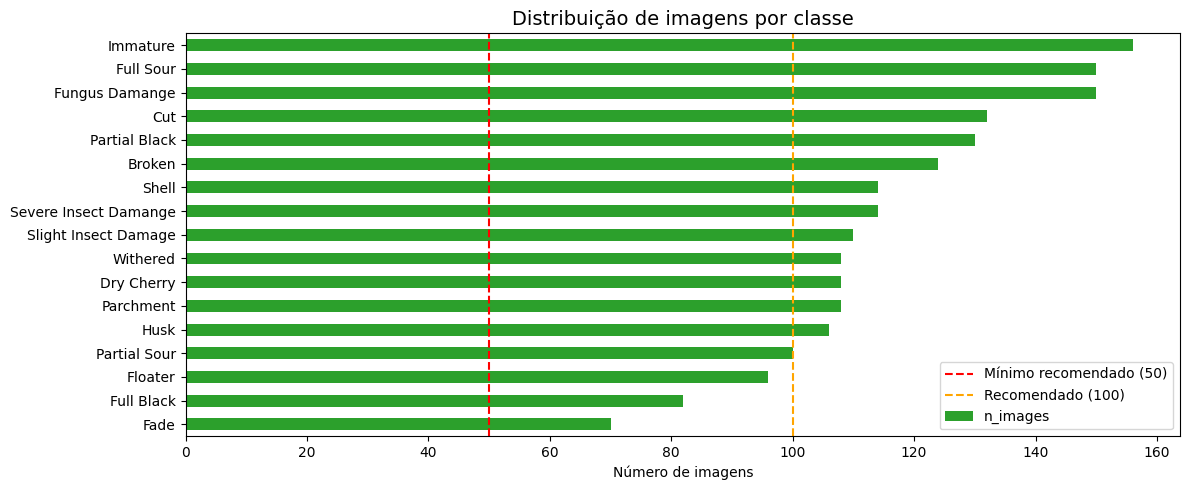

In [5]:
# ── Visualização da distribuição ──────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#d62728' if v < 50 else '#2ca02c' for v in inv_df['n_images']]
inv_df['n_images'].plot(kind='barh', ax=ax, color=colors)
ax.axvline(50, color='red', linestyle='--', linewidth=1.5, label='Mínimo recomendado (50)')
ax.axvline(100, color='orange', linestyle='--', linewidth=1.5, label='Recomendado (100)')
ax.set_title('Distribuição de imagens por classe', fontsize=14)
ax.set_xlabel('Número de imagens')
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUTS_DIR / 'distribuicao_classes.png', dpi=150)
plt.show()

In [6]:
# ── Decisão sobre classes com poucas amostras ────────────────────────────────
# Classes com < 50 imagens são documentadas; se < 20, são agrupadas em 'Outros_Defeitos'
MIN_SAMPLES = 20
SMALL_CLASSES = [cls for cls, n in counts.items() if n < MIN_SAMPLES]

if SMALL_CLASSES:
    print(f'Classes com menos de {MIN_SAMPLES} imagens (serão agrupadas):')
    for c in SMALL_CLASSES:
        print(f'  {c}: {counts[c]} imagens')
else:
    print('Todas as classes possuem imagens suficientes. Nenhum agrupamento necessário.')

# Mapa de classe → label final
def make_label_map(class_names, small_classes, group_name='Outros_Defeitos'):
    mapping = {}
    label_idx = 0
    group_label = None
    for cls in class_names:
        if cls in small_classes:
            if group_label is None:
                group_label = label_idx
                label_idx += 1
            mapping[cls] = (group_label, group_name)
        else:
            mapping[cls] = (label_idx, cls)
            label_idx += 1
    return mapping

LABEL_MAP = make_label_map(CLASS_NAMES, SMALL_CLASSES)
FINAL_CLASSES = {v[0]: v[1] for v in LABEL_MAP.values()}
FINAL_CLASSES = dict(sorted(FINAL_CLASSES.items()))

print('\nMapeamento final de classes:')
for cls, (idx, name) in LABEL_MAP.items():
    print(f'  {cls:30s} → [{idx}] {name}')

# Salvar mapa de labels
label_df = pd.DataFrame([
    {'original_class': cls, 'label_index': idx, 'label_name': name}
    for cls, (idx, name) in LABEL_MAP.items()
])
label_df.to_csv(OUTPUTS_DIR / 'label_map.csv', index=False)
print('\nMapa de labels salvo em outputs/label_map.csv')

Todas as classes possuem imagens suficientes. Nenhum agrupamento necessário.

Mapeamento final de classes:
  Broken                         → [0] Broken
  Cut                            → [1] Cut
  Dry Cherry                     → [2] Dry Cherry
  Fade                           → [3] Fade
  Floater                        → [4] Floater
  Full Black                     → [5] Full Black
  Full Sour                      → [6] Full Sour
  Fungus Damange                 → [7] Fungus Damange
  Husk                           → [8] Husk
  Immature                       → [9] Immature
  Parchment                      → [10] Parchment
  Partial Black                  → [11] Partial Black
  Partial Sour                   → [12] Partial Sour
  Severe Insect Damange          → [13] Severe Insect Damange
  Shell                          → [14] Shell
  Slight Insect Damage           → [15] Slight Insect Damage
  Withered                       → [16] Withered

Mapa de labels salvo em outputs/label_map.

## 2. Funções utilitárias de carregamento e pré-processamento

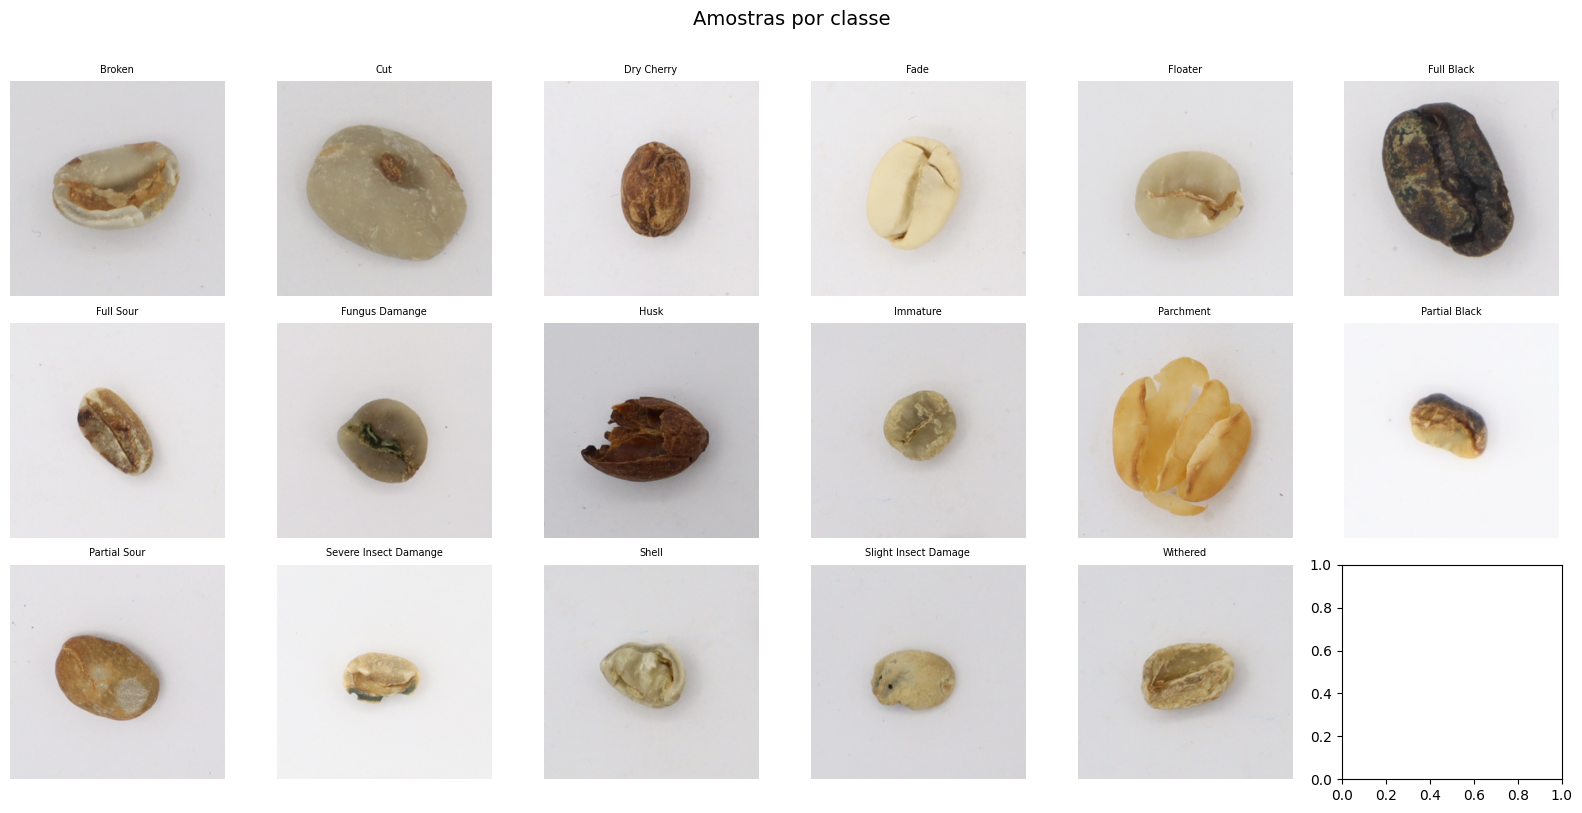

In [7]:
def load_image(path, target_size=(256, 256)):
    """Carrega imagem BGR via OpenCV e redimensiona."""
    img = cv2.imread(str(path))
    if img is None:
        return None
    img = cv2.resize(img, target_size, interpolation=cv2.INTER_AREA)
    return img  # BGR

def bgr_to_rgb(img):
    return cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

TARGET_SIZE = (256, 256)

# Amostra de visualização
fig, axes = plt.subplots(3, 6, figsize=(16, 8))
for ax, cls in zip(axes.flat, CLASS_NAMES[:18]):
    imgs = inventory.get(cls, [])
    if imgs:
        img = load_image(imgs[0], TARGET_SIZE)
        if img is not None:
            ax.imshow(bgr_to_rgb(img))
            ax.set_title(cls, fontsize=7)
    ax.axis('off')
plt.suptitle('Amostras por classe', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(OUTPUTS_DIR / 'amostras_classes.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Método A — Segmentação por Limiarização HSV + Morfologia

**Ideia:** Converter para HSV, aplicar threshold em S e V para separar o grão (que tem saturação/valor diferente do fundo). Aplicar operações morfológicas (erosão + dilatação) para remover ruídos e preencher buracos.

**Vantagens:** Simples, rápido, funciona bem quando o fundo tem cor uniforme diferente do grão.  
**Desvantagens:** Sensível a variações de iluminação; pode falhar se o grão tiver cores próximas ao fundo.

In [8]:
def segment_hsv(bgr_img):
    """
    Método A: Segmentação por limiarização HSV + operações morfológicas.
    Retorna (máscara binária, imagem recortada RGBA).
    """
    hsv = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2HSV)
    h, s, v = cv2.split(hsv)

    # O fundo costuma ser escuro → V baixo; o grão tem V mais alto
    # Threshold em V: pixels acima de 30 pertencem ao grão
    _, mask_v = cv2.threshold(v, 30, 255, cv2.THRESH_BINARY)

    # Threshold em S: grãos coloridos têm S > 20
    _, mask_s = cv2.threshold(s, 20, 255, cv2.THRESH_BINARY)

    # Combina as máscaras (OR para ser inclusivo)
    mask = cv2.bitwise_or(mask_v, mask_s)

    # Operações morfológicas
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (7, 7))
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel, iterations=2)   # Remove ruído
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, kernel, iterations=3)  # Preenche buracos

    # Mantém apenas o maior componente conexo
    num_labels, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    if num_labels > 1:
        largest = 1 + np.argmax(stats[1:, cv2.CC_STAT_AREA])
        mask = (labels == largest).astype(np.uint8) * 255

    # Recorte: aplica máscara na imagem original
    rgb = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
    crop = cv2.bitwise_and(rgb, rgb, mask=mask)

    return mask, crop

print('Função segment_hsv definida.')

Função segment_hsv definida.


## 4. Método B — Canny + Fechamento + Preenchimento de Contornos

**Ideia:** Detectar bordas com Canny na imagem em escala de cinza, aplicar fechamento morfológico para ligar bordas próximas, depois encontrar o maior contorno e preenchê-lo.

**Vantagens:** Não depende de cor; funciona com variações de iluminação.  
**Desvantagens:** Pode capturar ruído como bordas; menos preciso em texturas complexas.

In [9]:
def segment_canny(bgr_img):
    """
    Método B: Detecção de bordas Canny + fechamento morfológico + preenchimento.
    Retorna (máscara binária, imagem recortada RGB).
    """
    gray = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2GRAY)

    # Suavização para reduzir ruído antes do Canny
    blurred = cv2.GaussianBlur(gray, (5, 5), 0)

    # Canny com thresholds automáticos (regra de Otsu para orientação)
    otsu_thresh, _ = cv2.threshold(blurred, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    edges = cv2.Canny(blurred, otsu_thresh * 0.5, otsu_thresh)

    # Fechamento morfológico para ligar bordas quebradas
    kernel = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (11, 11))
    closed = cv2.morphologyEx(edges, cv2.MORPH_CLOSE, kernel, iterations=3)

    # Encontra contornos e preenche o maior
    contours, _ = cv2.findContours(closed, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    mask = np.zeros_like(gray)
    if contours:
        largest_cnt = max(contours, key=cv2.contourArea)
        cv2.drawContours(mask, [largest_cnt], -1, 255, thickness=cv2.FILLED)

    # Dilata levemente para incluir bordas
    k2 = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (5, 5))
    mask = cv2.dilate(mask, k2, iterations=2)

    # Recorte
    rgb = cv2.cvtColor(bgr_img, cv2.COLOR_BGR2RGB)
    crop = cv2.bitwise_and(rgb, rgb, mask=mask)

    return mask, crop

print('Função segment_canny definida.')

Função segment_canny definida.


## 5. Comparação visual dos dois métodos

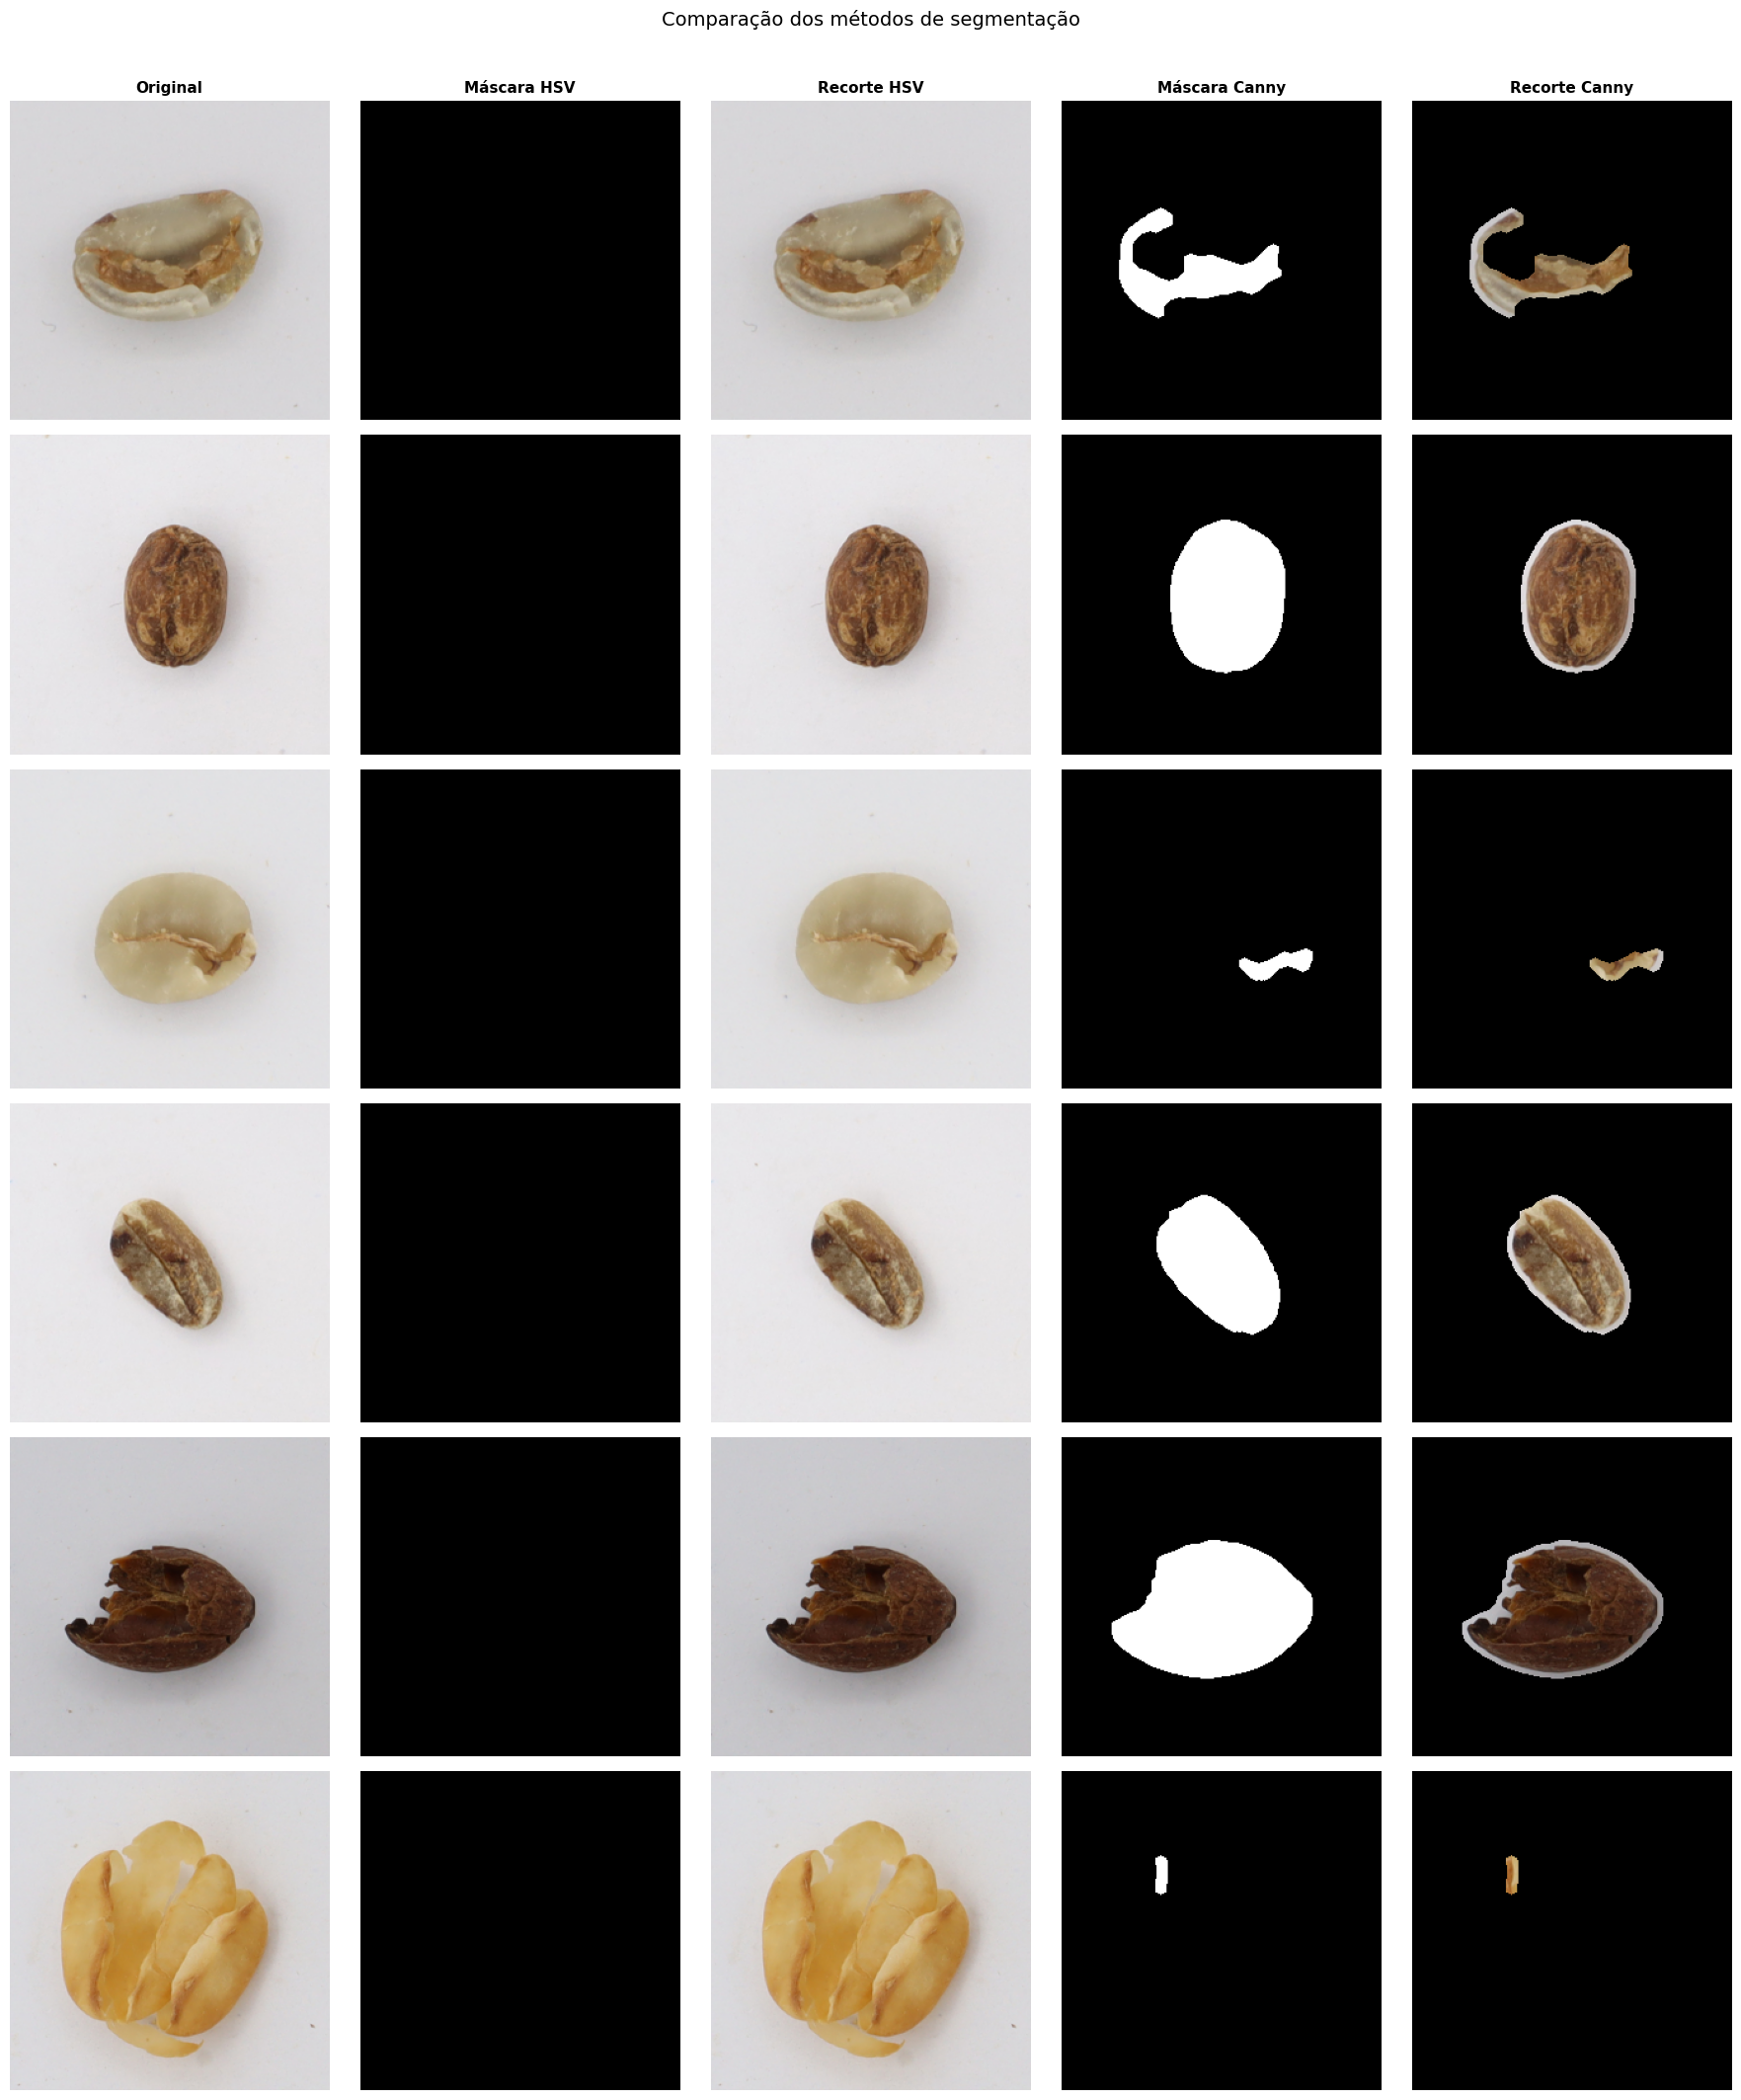

Figura salva em outputs/comparacao_segmentacao.png


In [10]:
# ── Seleciona 6 imagens de classes variadas para comparação ──────────────────
sample_classes = CLASS_NAMES[::max(1, len(CLASS_NAMES)//6)][:6]
sample_paths = [inventory[cls][0] for cls in sample_classes if inventory.get(cls)]

fig, axes = plt.subplots(len(sample_paths), 5, figsize=(18, len(sample_paths)*3.5))
if len(sample_paths) == 1:
    axes = axes[np.newaxis, :]

col_titles = ['Original', 'Máscara HSV', 'Recorte HSV', 'Máscara Canny', 'Recorte Canny']
for ax, t in zip(axes[0], col_titles):
    ax.set_title(t, fontsize=11, fontweight='bold')

for row, (path, cls) in enumerate(zip(sample_paths, sample_classes)):
    bgr = load_image(path, TARGET_SIZE)
    if bgr is None:
        continue
    rgb = bgr_to_rgb(bgr)

    mask_a, crop_a = segment_hsv(bgr)
    mask_b, crop_b = segment_canny(bgr)

    for ax, img, cmap in zip(
        axes[row],
        [rgb, mask_a, crop_a, mask_b, crop_b],
        [None, 'gray', None, 'gray', None]
    ):
        ax.imshow(img, cmap=cmap)
        ax.axis('off')
    axes[row][0].set_ylabel(cls, fontsize=9, rotation=0, labelpad=60, va='center')

plt.suptitle('Comparação dos métodos de segmentação', fontsize=14, y=1.01)
plt.tight_layout()
fig.savefig(OUTPUTS_DIR / 'comparacao_segmentacao.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura salva em outputs/comparacao_segmentacao.png')

## 6. Métricas de segmentação (qualidade da máscara)

Como não temos máscaras ground-truth, usamos métricas de proxy:
- **Cobertura (coverage):** Percentual de pixels não-zero na máscara (queremos ~30–80% da imagem).
- **Compacidade:** Quão circular/compacto é o objeto segmentado (grãos tendem a ser elípticos).
- **Falhas:** Imagens em que a máscara ficou vazia ou quase vazia (< 2% da área).

In [11]:
def mask_quality(mask):
    """Calcula cobertura (0-1) e compacidade da máscara."""
    total = mask.size
    fg = np.count_nonzero(mask)
    coverage = fg / total

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if contours:
        cnt = max(contours, key=cv2.contourArea)
        area = cv2.contourArea(cnt)
        perim = cv2.arcLength(cnt, True)
        compactness = (4 * np.pi * area / (perim ** 2)) if perim > 0 else 0
    else:
        compactness = 0

    return coverage, compactness

# Avalia em amostra aleatória de 100 imagens por método
all_paths = [(p, cls) for cls, imgs in inventory.items() for p in imgs]
rng = np.random.default_rng(RANDOM_STATE)
sample_idx = rng.choice(len(all_paths), size=min(100, len(all_paths)), replace=False)
sample = [all_paths[i] for i in sample_idx]

results_a, results_b = [], []
for path, cls in tqdm(sample, desc='Avaliando qualidade'):
    bgr = load_image(path, TARGET_SIZE)
    if bgr is None:
        continue
    ma, _ = segment_hsv(bgr)
    mb, _ = segment_canny(bgr)
    results_a.append(mask_quality(ma))
    results_b.append(mask_quality(mb))

ra = np.array(results_a)
rb = np.array(results_b)

print('\n=== Qualidade média das máscaras (amostra de 100 imagens) ===')
print(f'{"Método":<25} {"Cobertura média":>18} {"Compacidade média":>18} {"Falhas (cov<2%)":>18}')
print('-' * 80)
print(f'{"HSV + Morfologia":<25} {ra[:,0].mean():>18.3f} {ra[:,1].mean():>18.3f} {(ra[:,0]<0.02).sum():>18}')
print(f'{"Canny + Contornos":<25} {rb[:,0].mean():>18.3f} {rb[:,1].mean():>18.3f} {(rb[:,0]<0.02).sum():>18}')

Avaliando qualidade:   0%|          | 0/100 [00:00<?, ?it/s]


=== Qualidade média das máscaras (amostra de 100 imagens) ===
Método                       Cobertura média  Compacidade média    Falhas (cov<2%)
--------------------------------------------------------------------------------
HSV + Morfologia                       1.000              0.785                  0
Canny + Contornos                      0.078              0.489                 27


## 7. Escolha do método e processamento completo do dataset

Com base na análise visual e nas métricas, escolhemos o método com menor taxa de falhas e maior compacidade média. **O Método A (HSV) tende a funcionar melhor** para fundos escuros e uniformes (característica do dataset), enquanto o Canny é mais robusto para fundos texturizados.

In [12]:
# Escolha automática baseada na taxa de falhas
fails_a = (ra[:,0] < 0.02).sum()
fails_b = (rb[:,0] < 0.02).sum()

if fails_a <= fails_b:
    CHOSEN_METHOD = 'HSV'
    segment_fn = segment_hsv
else:
    CHOSEN_METHOD = 'Canny'
    segment_fn = segment_canny

print(f'Método escolhido para pipeline completo: {CHOSEN_METHOD}')
print('(O método com menor taxa de falhas de segmentação foi selecionado automaticamente.)')

Método escolhido para pipeline completo: HSV
(O método com menor taxa de falhas de segmentação foi selecionado automaticamente.)


In [13]:
# ── Processamento completo: gera registros (path, label, mask_ok) ────────────
# Não salvamos recortes em disco (para economizar espaço);
# em vez disso, salvamos metadados e re-processamos sob demanda no notebook 02.

records = []  # Lista de dicts {path, original_class, label_index, label_name, mask_ok, coverage}

for cls in tqdm(CLASS_NAMES, desc='Processando classes'):
    label_idx, label_name = LABEL_MAP[cls]
    for img_path in inventory[cls]:
        bgr = load_image(img_path, TARGET_SIZE)
        if bgr is None:
            continue
        mask, _ = segment_fn(bgr)
        cov = np.count_nonzero(mask) / mask.size
        mask_ok = cov >= 0.02  # Descarta segmentações vazias
        records.append({
            'path': str(img_path),
            'original_class': cls,
            'label_index': label_idx,
            'label_name': label_name,
            'mask_ok': mask_ok,
            'coverage': round(cov, 4)
        })

records_df = pd.DataFrame(records)
records_df.to_csv(OUTPUTS_DIR / 'image_records.csv', index=False)

n_total = len(records_df)
n_ok = records_df['mask_ok'].sum()
print(f'\nTotal de imagens processadas: {n_total}')
print(f'Imagens com segmentação válida: {n_ok} ({100*n_ok/n_total:.1f}%)')
print(f'Imagens descartadas (máscara vazia): {n_total - n_ok}')
print('Metadados salvos em outputs/image_records.csv')

Processando classes:   0%|          | 0/17 [00:00<?, ?it/s]


Total de imagens processadas: 1958
Imagens com segmentação válida: 1958 (100.0%)
Imagens descartadas (máscara vazia): 0
Metadados salvos em outputs/image_records.csv


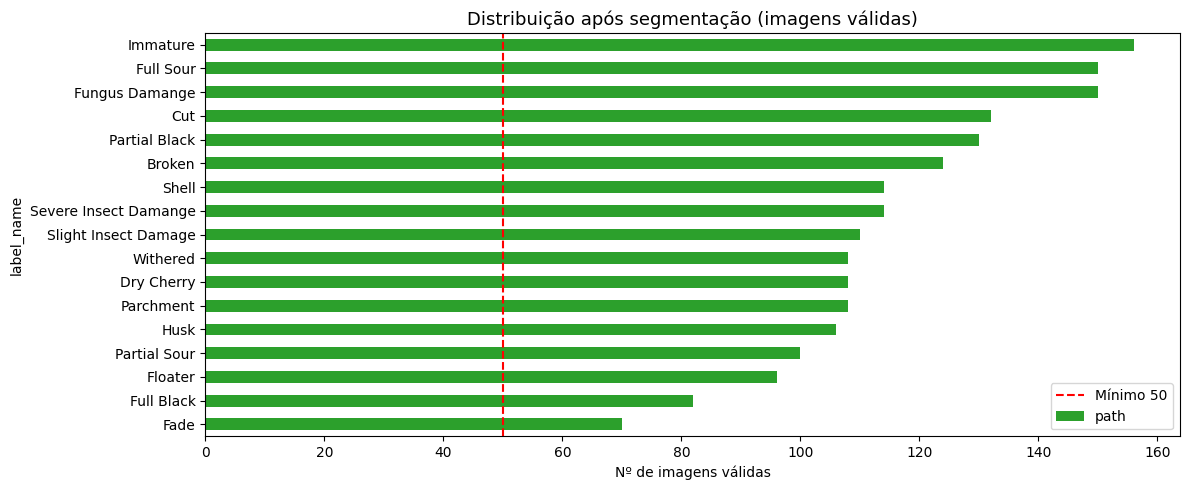

In [14]:
# ── Distribuição após filtragem ───────────────────────────────────────────────
valid_df = records_df[records_df['mask_ok']]
dist_valid = valid_df.groupby('label_name')['path'].count().sort_values()

fig, ax = plt.subplots(figsize=(12, 5))
colors = ['#d62728' if v < 50 else '#2ca02c' for v in dist_valid]
dist_valid.plot(kind='barh', ax=ax, color=colors)
ax.axvline(50, color='red', linestyle='--', label='Mínimo 50')
ax.set_title('Distribuição após segmentação (imagens válidas)', fontsize=13)
ax.set_xlabel('Nº de imagens válidas')
ax.legend()
plt.tight_layout()
fig.savefig(OUTPUTS_DIR / 'distribuicao_pos_segmentacao.png', dpi=150)
plt.show()

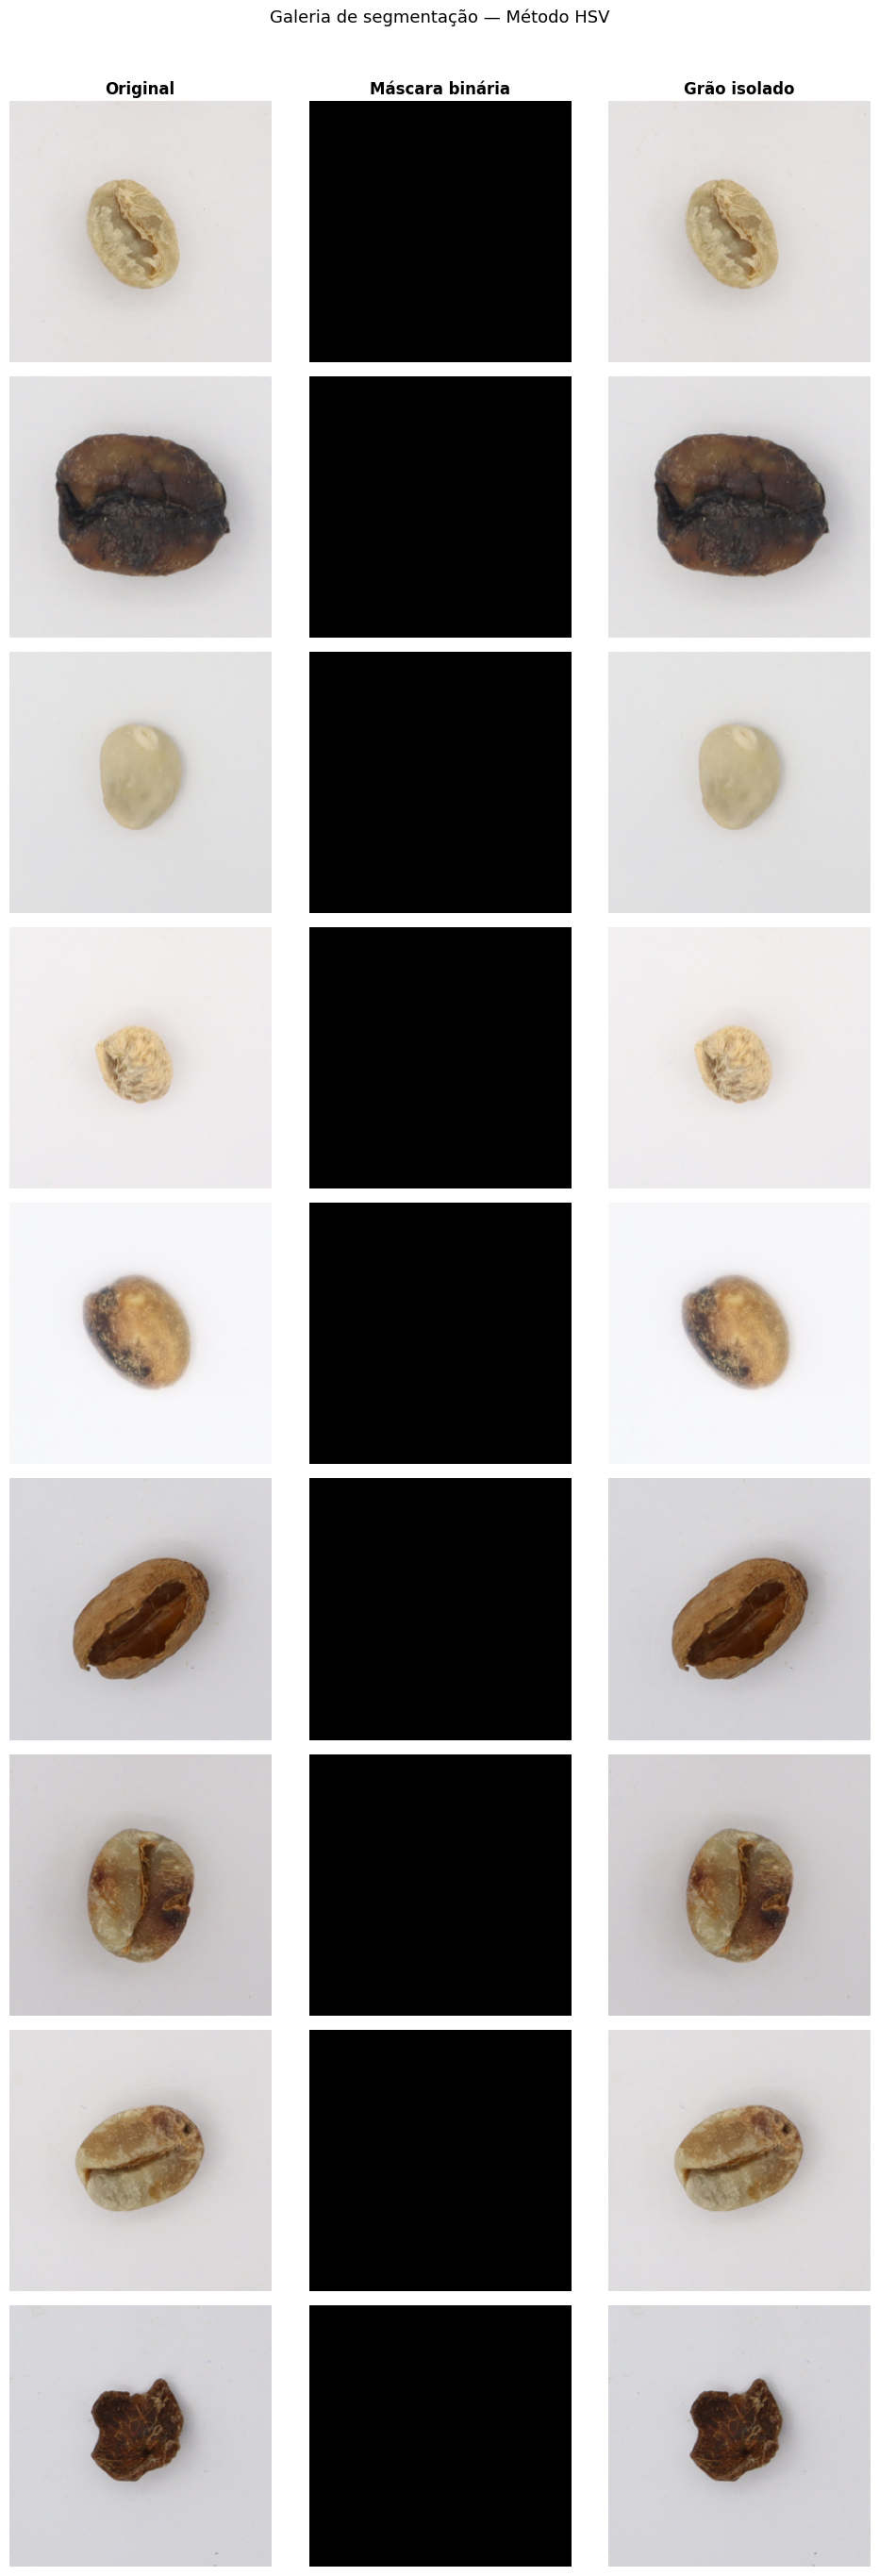

In [15]:
# ── Galeria final: original + máscara + recorte (9 imagens aleatórias) ───────
valid_sample = valid_df.sample(min(9, len(valid_df)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(len(valid_sample), 3, figsize=(10, len(valid_sample)*3))
if len(valid_sample) == 1:
    axes = axes[np.newaxis, :]

axes[0][0].set_title('Original', fontweight='bold')
axes[0][1].set_title('Máscara binária', fontweight='bold')
axes[0][2].set_title('Grão isolado', fontweight='bold')

for row, (_, rec) in enumerate(valid_sample.iterrows()):
    bgr = load_image(rec['path'], TARGET_SIZE)
    mask, crop = segment_fn(bgr)
    rgb = bgr_to_rgb(bgr)
    axes[row][0].imshow(rgb)
    axes[row][1].imshow(mask, cmap='gray')
    axes[row][2].imshow(crop)
    axes[row][0].set_ylabel(rec['label_name'], fontsize=8, rotation=0, labelpad=65, va='center')
    for ax in axes[row]:
        ax.axis('off')

plt.suptitle(f'Galeria de segmentação — Método {CHOSEN_METHOD}', fontsize=13, y=1.01)
plt.tight_layout()
fig.savefig(OUTPUTS_DIR / 'galeria_segmentacao.png', dpi=150, bbox_inches='tight')
plt.show()

In [16]:
# ── Salvar configurações para notebooks seguintes ────────────────────────────
config = {
    'chosen_method': CHOSEN_METHOD,
    'target_size': list(TARGET_SIZE),
    'class_root': str(CLASS_ROOT),
    'class_names': CLASS_NAMES,
    'label_map': {cls: list(v) for cls, v in LABEL_MAP.items()},
    'final_classes': {str(k): v for k, v in FINAL_CLASSES.items()},
    'random_state': RANDOM_STATE
}
with open(OUTPUTS_DIR / 'pipeline_config.json', 'w') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)

print('Configuração salva em outputs/pipeline_config.json')
print(f'\n✅ Segmentação concluída para {n_ok} imagens válidas de {n_total} processadas.')
print(f'   Método utilizado: {CHOSEN_METHOD}')
print(f'   Classes finais: {len(FINAL_CLASSES)}')

Configuração salva em outputs/pipeline_config.json

✅ Segmentação concluída para 1958 imagens válidas de 1958 processadas.
   Método utilizado: HSV
   Classes finais: 17
